(200, 2176)
(200,)
(200, 1344)
(200,)
(200, 2176)
(200,)
(200, 1344)
(200,)


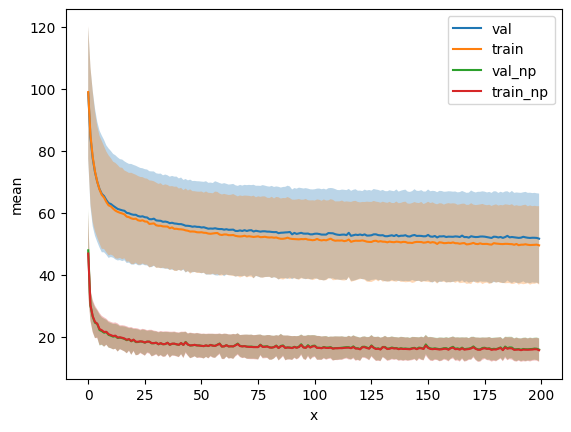

In [7]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

val_scores_path = "/home/pavel/data/goal-misgen/tmp/val_scores.npy"
# val_scores_path = "/home/pavel/code/goal-misgen/yrc-bench-fork/experiments/debug_ood/val_scores.npy"
training_scores_path = "/home/pavel/code/goal-misgen/yrc-bench-fork/experiments/debug_ood/training_scores.npy"

val_scores = np.load(val_scores_path)
training_scores = np.load(training_scores_path)

base_path = Path("/home/pavel/data/goal-misgen/tmp/")
score_paths = [
    ("val", base_path / "val_scores_3.npy"),
    ("train", base_path / "training_scores_3.npy"),
    ("val_np", base_path / "val_scores_no_preprocess.npy"),
    ("train_np", base_path / "training_scores_no_preprocess.npy"),
]

scores = []
for name, score in score_paths:
    scores.append((np.load(score), name))

for scores, name in scores: #, (training_scores, "train")]:

    print(scores.shape)

    mean_scores = np.mean(scores, axis=1)

    x = range(mean_scores.shape[0])
    std_scores = np.std(scores, axis=1)
    df = pd.DataFrame({
        "x": x,
        # "val_scores": val_scores,
        "mean": mean_scores,
        "std": std_scores
    })

    print(mean_scores.shape)

    # Plot means over episodes.
    sns.lineplot(
        data=df,
        x="x",
        y="mean",
        label=name,
    )

    plt.fill_between(df["x"], df["mean"] - df["std"], df["mean"] + df["std"], alpha=0.3)




Thresholds: [3.34451324e-05 4.63727803e-04 5.46759111e-04 6.06963004e-04
 6.64380299e-04 7.19635956e-04 7.76547648e-04 8.35095263e-04
 8.97878652e-04 9.71195928e-04 1.05221826e-03 1.14527089e-03
 1.25951960e-03 1.40907313e-03 1.61648728e-03 1.90227169e-03
 2.26740236e-03 2.81860888e-03 3.83312674e-03 2.95277648e-02]
Thresholds: [4.37383551e-06 1.07626605e-04 1.31853449e-04 1.52932174e-04
 1.71570369e-04 1.88977771e-04 2.07429868e-04 2.27718760e-04
 2.49195098e-04 2.72753082e-04 2.98305036e-04 3.28126771e-04
 3.61067010e-04 4.01740765e-04 4.56356152e-04 5.30851545e-04
 6.25072902e-04 7.76175177e-04 1.10085844e-03 3.33134495e-02]
Thresholds: [3.09185998e-05 3.78899364e-04 4.48238425e-04 4.96541674e-04
 5.37286396e-04 5.77412533e-04 6.17146700e-04 6.58419449e-04
 7.03947095e-04 7.56288244e-04 8.16331885e-04 8.86121474e-04
 9.69951681e-04 1.08150782e-03 1.22971995e-03 1.43776275e-03
 1.67893840e-03 2.06092140e-03 2.71461956e-03 2.17920467e-02]
Thresholds: [3.58223915e-05 3.88085842e-04 4.9

ValueError: Found 17 'None' results

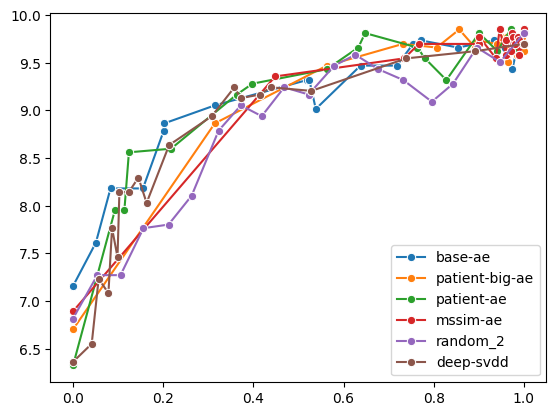

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_path = Path("/home/pavel/data/goal-misgen/tmp")

eval_path = base_path / "09-eval-20-thresh" 
evals = [
    "base-ae", "patient-big-ae", "patient-ae", "mssim-ae", "random_2", "deep-svdd", "debug-mssim-test"
]

# eval_path = base_path / "10-eval-no-bg"
# evals = ["random"]

for eval in evals:

    data_path = eval_path / f"{eval}.npz"

    eval_data = np.load(data_path, allow_pickle=True)

    results = eval_data["results"]

    thresholds = eval_data["thresholds"]

    split = "test"

    mean_rewards = []
    std_rewards = []
    afh_percentage = []

    # Count the number of 'None' results
    num_none = sum(1 if result is None else 0 for result in results)
    if num_none > 0:
        print(f"Number of 'None' results: {num_none}")
        print(f"Results: {results}")
        raise ValueError(f"Found {num_none} 'None' results")

    for result in results:
        mean_rewards.append(result[split]["reward_mean"])
        std_rewards.append(result[split]["reward_std"])
        afh_percentage.append(result[split]["action_1_frac"])

    # Calculate ask for help precentage for each threshold.
    # train_ood_percentage = []

    # training_scores = eval_data["training_scores"]
    # if training_scores is not None:
    #     for threshold in thresholds:
    #         if threshold is None:
    #             raise ValueError("Threshold is None")
    #         num_larger = np.sum(training_scores > threshold)
    #         train_ood_percentage.append(num_larger / len(training_scores))
    # else:
    #     train_ood_percentage = None


    # print(f"Ask for help percentage: {train_ood_percentage}")

    # print(f"Thresholds: {thresholds}")

    # Plot lineplot using seaborn.
    sns.lineplot(x=afh_percentage, y=mean_rewards, label=eval, marker="o")

plt.xlabel("Ask for help percentage (test)")
plt.ylabel("Mean reward")
plt.title("Mean reward vs. ask for help percentage")
plt.legend()
plt.show()

# Plot lineplot using matplotlib.
# plt.plot(thresholds, mean_rewards)
# plt.fill_between(thresholds, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.5)
# plt.show()



# print(eval_data["thresholds"])

# print(eval_data["scores"])